In [50]:
from py_files.setup import *
setup_notebook()

import py_files.elas as elas
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Effect of $\varepsilon^S$ and $\phi$ on `wages` and `welfare`

**Goal:** Describe effect of the `capital supply elasticity` and of the friction of moving between sectors, i.e.
\begin{align*}
    \frac{d\log w_C}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log w_I}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \frac{d\log r_K}{d\log (1-\tau_t)}(\varepsilon^S), \quad
    \varepsilon^S(\varphi).
\end{align*}
To discuss the effect of the `capital supply elasticity` and relation to NCM, through *Chamley-Judd*.

**Output:**

1. Plot the wage/rent effects in $(w_I/r_K, \varepsilon^S)$.
2. Plot the wage/rent effects in $(w_I/r_K, \phi)$.
3. Do the simulation for some chosen elasticities.

In [51]:
m = CapIncModel_single()
out = m.calibrate()


 Calibrate household: zero wage premia + target eps_nI 
targets    prem1=0, prem2=0, eps1=1.0
------------------------------------------------------------
old        mu1=0.26   =>
           log(w1I/w1C)=-1.07e-01

old        phi1=0.30 =>
           eps1=0.224
------------------------------------------------------------
new        mu1=0.2340   =>
           log(w1I/w1C)=-2.08e-13

new        phi1=1.3056 =>
           eps1=1.000



*`1. assess elasticities`*

Baseline epsD    = 1.4798
Baseline epsS_LR = 1.7417
Baseline epsS_SR = 0.1365


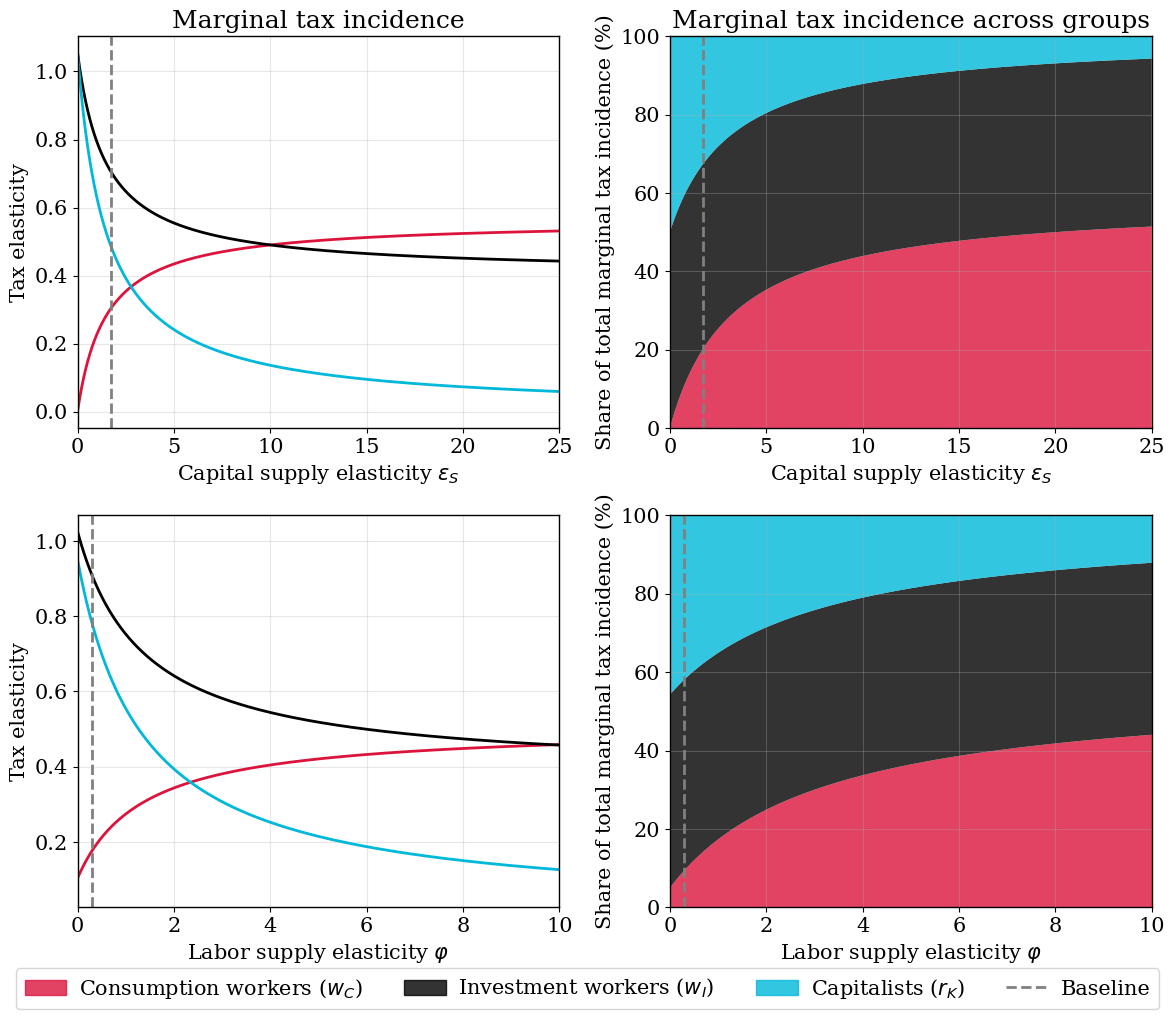


── epsS spot checks ──
epsS=    0.10  |  wC= 0.036  wI= 1.015  rK= 0.989  |  shares: 2% / 50% / 48%
epsS=    1.00  |  wC= 0.227  wI= 0.794  rK= 0.630  |  shares: 14% / 48% / 38%
epsS=    1.74  |  wC= 0.304  wI= 0.705  rK= 0.485  |  shares: 20% / 47% / 32%
epsS=   10.00  |  wC= 0.490  wI= 0.490  rK= 0.136  |  shares: 44% / 44% / 12%
epsS=   25.00  |  wC= 0.531  wI= 0.443  rK= 0.059  |  shares: 51% / 43% / 6%

── phi spot checks ──
phi= 0.10  epsD= 1.352  epsS= 0.410  |  wC= 0.131  wI= 0.982  rK= 0.887  |  shares: 7% / 49% / 44%
phi= 0.50  epsD= 1.393  epsS= 0.840  |  wC= 0.212  wI= 0.853  rK= 0.700  |  shares: 12% / 48% / 40%
phi= 0.30  epsD= 1.372  epsS= 0.625  |  wC= 0.176  wI= 0.909  rK= 0.782  |  shares: 9% / 49% / 42%
phi= 3.00  epsD= 1.644  epsS= 3.450  |  wC= 0.381  wI= 0.582  rK= 0.307  |  shares: 30% / 46% / 24%
phi=10.00  epsD= 2.286  epsS=10.116  |  wC= 0.459  wI= 0.457  rK= 0.126  |  shares: 44% / 44% / 12%


In [57]:
# ── 1. Baseline + epsS sweep ─────────────────────────────────────────────────
out_base = elas.dem_sup_elas(m, tau=0.0)
epsD_baseline = out_base['epsD']

print(f"Baseline epsD    = {epsD_baseline:.4f}")
print(f"Baseline epsS_LR = {out_base['epsS_LR']:.4f}")
print(f"Baseline epsS_SR = {out_base['epsS_SR']:.4f}")

epsS_grid = np.linspace(0.01, 25, 2000)

w_C_S, w_I_S, r_K_S = [], [], []
for epsS in epsS_grid:
    res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=epsS)
    w_C_S.append(res['w_C_elas'])
    w_I_S.append(res['w_I_elas'])
    r_K_S.append(res['r_K_elas'])

w_C_S = np.array(w_C_S)
w_I_S = np.array(w_I_S)
r_K_S = np.array(r_K_S)

total_S    = w_C_S + w_I_S + r_K_S
share_wC_S = w_C_S / total_S * 100
share_wI_S = w_I_S / total_S * 100
share_rK_S = r_K_S / total_S * 100
epsS_base  = out_base['epsS_LR']

# ── 2. phi sweep ─────────────────────────────────────────────────────────────
phi_grid = np.linspace(0.01, 20, 2000)

w_C_P, w_I_P, r_K_P = [], [], []


for phi in phi_grid:
    m.phi1 = phi
    out = elas.dem_sup_elas(m, tau=0.0)
    res = elas.wr_tax_elas(m, elas_out=out)

    out_fixed = elas.dem_sup_elas(m, tau=0.0)   
    epsD_fixed = out_fixed['epsD']
    res = elas.wr_tax_elas(m, elas_out=out, epsD=epsD_fixed)  
    
    w_C_P.append(res['w_C_elas'])
    w_I_P.append(res['w_I_elas'])
    r_K_P.append(res['r_K_elas'])

m.phi1 = 1.35   # restore

w_C_P = np.array(w_C_P)
w_I_P = np.array(w_I_P)
r_K_P = np.array(r_K_P)

total_P    = w_C_P + w_I_P + r_K_P
share_wC_P = w_C_P / total_P * 100
share_wI_P = w_I_P / total_P * 100
share_rK_P = r_K_P / total_P * 100
phi_base   = 0.3

# ── 3. Plot ───────────────────────────────────────────────────────────────────
colors = ['crimson', 'k', '#00B8D9']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Row 1: epsS sweep ---
ax = axes[0, 0]
ax.plot(epsS_grid, w_C_S, color=colors[0], lw=2)
ax.plot(epsS_grid, w_I_S, color=colors[1], lw=2)
ax.plot(epsS_grid, r_K_S, color=colors[2], lw=2)
ax.axvline(epsS_base, color='grey', ls='--', lw=2)
ax.set_xlabel(r'Capital supply elasticity $\varepsilon_S$')
ax.set_ylabel('Tax elasticity')
ax.set_title('Marginal tax incidence')
ax.set_xlim(0, 25)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.stackplot(epsS_grid, share_wC_S, share_wI_S, share_rK_S,
             colors=colors, alpha=0.8)
ax.axvline(epsS_base, color='grey', ls='--', lw=2)
ax.set_xlabel(r'Capital supply elasticity $\varepsilon_S$')
ax.set_ylabel('Share of total marginal tax incidence (%)')
ax.set_title('Marginal tax incidence across groups')
ax.set_xlim(0, 25)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# --- Row 2: phi sweep ---
ax = axes[1, 0]
ax.plot(phi_grid, w_C_P, color=colors[0], lw=2)
ax.plot(phi_grid, w_I_P, color=colors[1], lw=2)
ax.plot(phi_grid, r_K_P, color=colors[2], lw=2)
ax.axvline(phi_base, color='grey', ls='--', lw=2)
ax.set_xlabel(r'Labor supply elasticity $\varphi$')
ax.set_ylabel('Tax elasticity')
ax.set_xlim(0, 10)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.stackplot(phi_grid, share_wC_P, share_wI_P, share_rK_P,
             colors=colors, alpha=0.8)
ax.axvline(phi_base, color='grey', ls='--', lw=2)
ax.set_xlabel(r'Labor supply elasticity $\varphi$')
ax.set_ylabel('Share of total marginal tax incidence (%)')
ax.set_xlim(0, 10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# ── Shared legend below all panels ───────────────────────────────────────────
legend_handles = [
    Patch(color=colors[0], alpha=0.8, label=r'Consumption workers ($w_C$)'),
    Patch(color=colors[1], alpha=0.8, label=r'Investment workers ($w_I$)'),
    Patch(color=colors[2], alpha=0.8, label=r'Capitalists ($r_K$)'),
    Line2D([0], [0], color='grey', ls='--', lw=2, label='Baseline'),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.03),
    frameon=True,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

# ── Spot checks ───────────────────────────────────────────────────────────────
print("\n── epsS spot checks ──")
for eps in [0.1, 1.0, epsS_base, 10, 25]:
    res = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=eps)
    tot = sum(res.values())
    print(f"epsS={eps:8.2f}  |  wC={res['w_C_elas']:6.3f}  wI={res['w_I_elas']:6.3f}  rK={res['r_K_elas']:6.3f}  |  shares: {res['w_C_elas']/tot*100:.0f}% / {res['w_I_elas']/tot*100:.0f}% / {res['r_K_elas']/tot*100:.0f}%")

print("\n── phi spot checks ──")
for phi in [0.1, 0.5, phi_base, 3.0, 10.0]:
    m.phi1 = phi
    out = elas.dem_sup_elas(m, tau=0.0)
    res = elas.wr_tax_elas(m, elas_out=out)
    tot = sum(res.values())
    print(f"phi={phi:5.2f}  epsD={out['epsD']:6.3f}  epsS={out['epsS_LR']:6.3f}  |  wC={res['w_C_elas']:6.3f}  wI={res['w_I_elas']:6.3f}  rK={res['r_K_elas']:6.3f}  |  shares: {res['w_C_elas']/tot*100:.0f}% / {res['w_I_elas']/tot*100:.0f}% / {res['r_K_elas']/tot*100:.0f}%")

m.phi1 = 1.35   # restore